# 21 — Evaluate Audio Model

Loads the best checkpoint for each trained audio model and runs full test-set
evaluation: classification report, confusion matrix, and inference speed.

**Depends on:** `02_preprocess_audio.ipynb` (run automatically below).

**Reads from** `../experiments/audio_unimodal/<version>/<model_slug>/model/`.

**Writes to each run directory:**
- `classification_report_test.json`
- `confusion_matrix_test.png`
- `eval_metrics.json`

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Train: 9,988 | Dev: 1,108 | Test: 2,610
Duration stats (sampled 500 files):
  mean  : 3.23 s
  median: 2.43 s
  max   : 41.05 s
  >MAX_AUDIO_S (10.0s): 14 clips


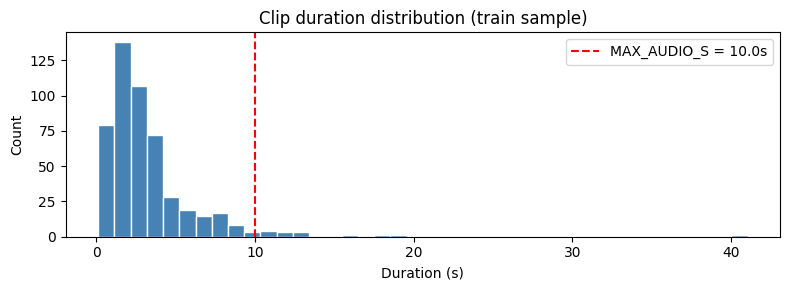

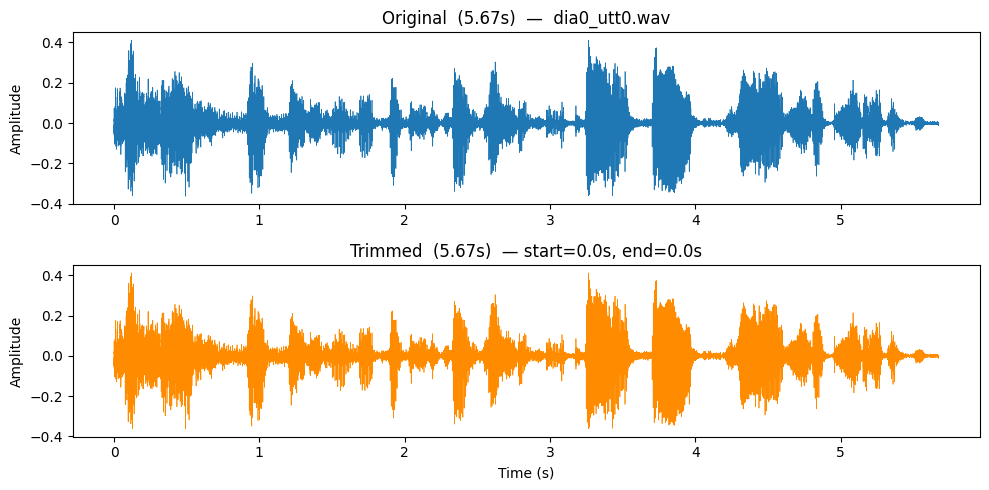

[train] OK — 9,988 rows
[dev] OK — 1,108 rows
[test] OK — 2,610 rows


In [1]:
# Imports train_df_audio, dev_df_audio, test_df_audio, label2id, id2label
%run 02_preprocess_audio.ipynb

In [2]:
import os
import pandas as pd

from src.config import (
    AUDIO_MODELS_TO_RUN, AUDIO_TEST_DIR, DEVICE,
    EXP_ROOT_AUDIO, MAX_AUDIO_S, TRIM_END_S, TRIM_START_S, VERSION,
)
from src.evaluation.evaluate_audio import run_full_audio_evaluation
from src.training.utils import slugify

## Discover run directories

In [3]:
def find_run_dir(model_name: str) -> str:
    slug = slugify(model_name)
    path = os.path.join(EXP_ROOT_AUDIO, VERSION, slug)
    assert os.path.isdir(path), (
        f'Run directory not found: {path}\nRun 11_train_audio_model.ipynb first.'
    )
    return path

run_dirs = [find_run_dir(m) for m in AUDIO_MODELS_TO_RUN]
print('Evaluating:', run_dirs)

Evaluating: ['../experiments/audio_unimodal\\v1\\facebook_wav2vec2_base', '../experiments/audio_unimodal\\v1\\ntu_spml_distilhubert']


## Run evaluation

Trim and max-duration settings are loaded from the run's own `config.json`
so evaluation is consistent with how the model was trained.

In [7]:
import json

all_results = {}

for model_name, run_dir in zip(AUDIO_MODELS_TO_RUN, run_dirs):
    print(f'\n=== {model_name} ===')

    # Read trim/max_audio from the config saved during training
    run_cfg = json.load(open(os.path.join(run_dir, 'config.json')))
    trim_start = run_cfg.get('trim_start_s', TRIM_START_S)
    trim_end   = run_cfg.get('trim_end_s',   TRIM_END_S)
    max_audio  = run_cfg.get('max_audio_s',  MAX_AUDIO_S)

    results = run_full_audio_evaluation(
        run_dir=run_dir,
        test_df=test_df_audio,
        id2label=id2label,
        device=DEVICE,
        audio_test_dir=AUDIO_TEST_DIR,
        trim_start_s=trim_start,
        trim_end_s=trim_end,
        max_audio_s=max_audio,
    )
    all_results[model_name] = results

    print(f'  Accuracy    : {results["accuracy"]:.4f}')
    print(f'  Macro F1    : {results["macro_f1"]:.4f}')
    print(f'  Weighted F1 : {results["weighted_f1"]:.4f}')
    print(f'  Infer ms/sample (bs=1): {results["inference_ms_per_sample_bs1"]:.2f}')


=== facebook/wav2vec2-base ===


Loading weights: 100%|██████████| 215/215 [00:00<00:00, 980.56it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


  Accuracy    : 0.4268
  Macro F1    : 0.2507
  Weighted F1 : 0.4273
  Infer ms/sample (bs=1): 19.25

=== ntu-spml/distilhubert ===


Loading weights: 100%|██████████| 53/53 [00:00<00:00, 850.20it/s, Materializing param=projector.weight]                                                    


  Accuracy    : 0.4299
  Macro F1    : 0.2226
  Weighted F1 : 0.4096
  Infer ms/sample (bs=1): 6.33


## Side-by-side summary

In [8]:
summary = pd.DataFrame([
    {
        'model':        name,
        'accuracy':     r['accuracy'],
        'macro_f1':     r['macro_f1'],
        'weighted_f1':  r['weighted_f1'],
        'infer_ms_bs1': r['inference_ms_per_sample_bs1'],
    }
    for name, r in all_results.items()
])
summary

,model,accuracy,macro_f1,weighted_f1,infer_ms_bs1
0,facebook/wav2vec2-base,0.426820,0.250688,0.427317,19.247367
1,ntu-spml/distilhubert,0.429885,0.222618,0.409600,6.329970


## Confusion matrices

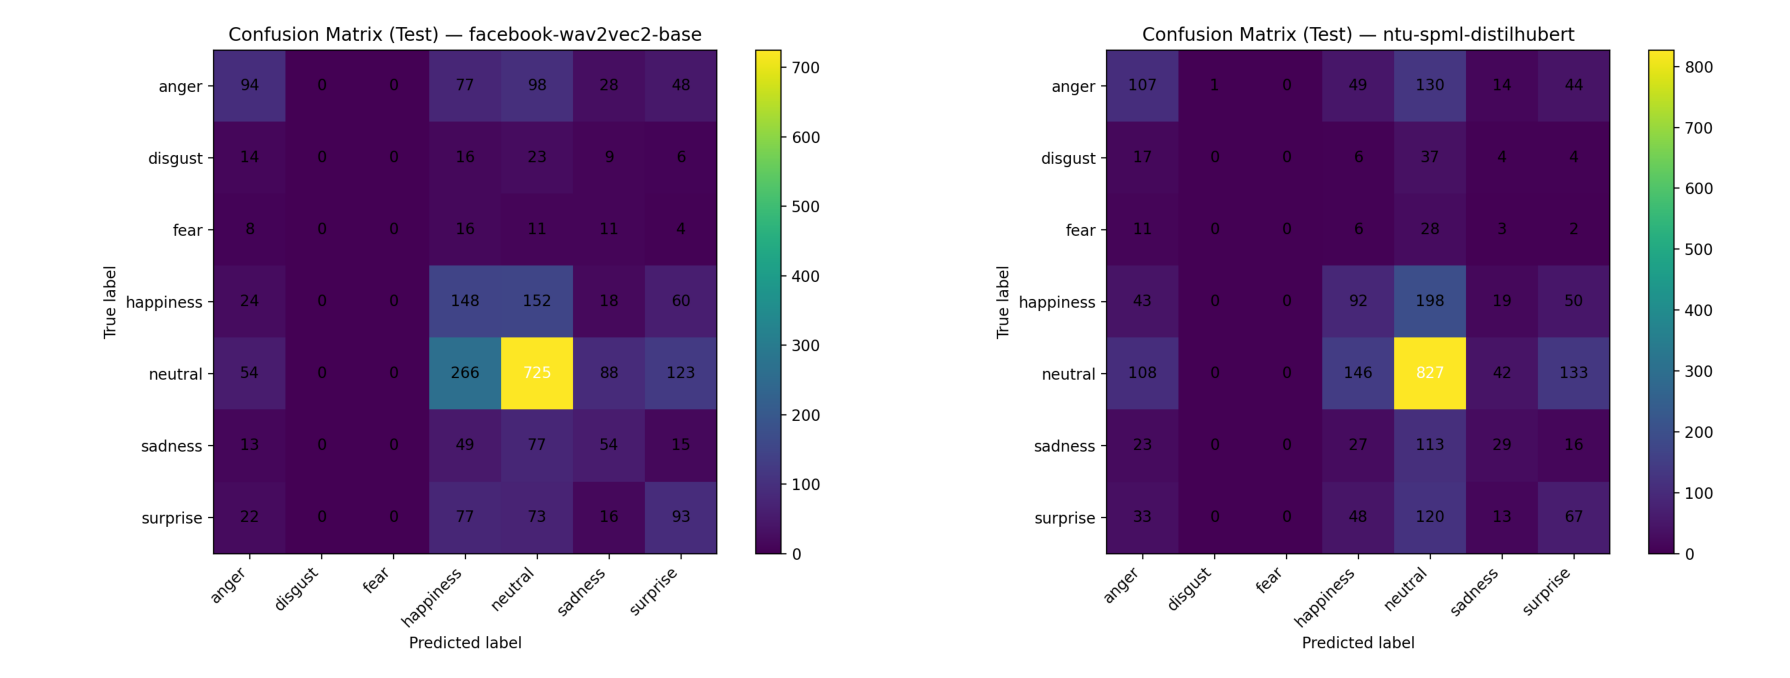

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, len(run_dirs), figsize=(9 * len(run_dirs), 7), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs):
    img_path = os.path.join(run_dir, 'confusion_matrix_test.png')
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
    ax.axis('off')

plt.tight_layout()
plt.show()